refined_portfolio_graph_spacious.png


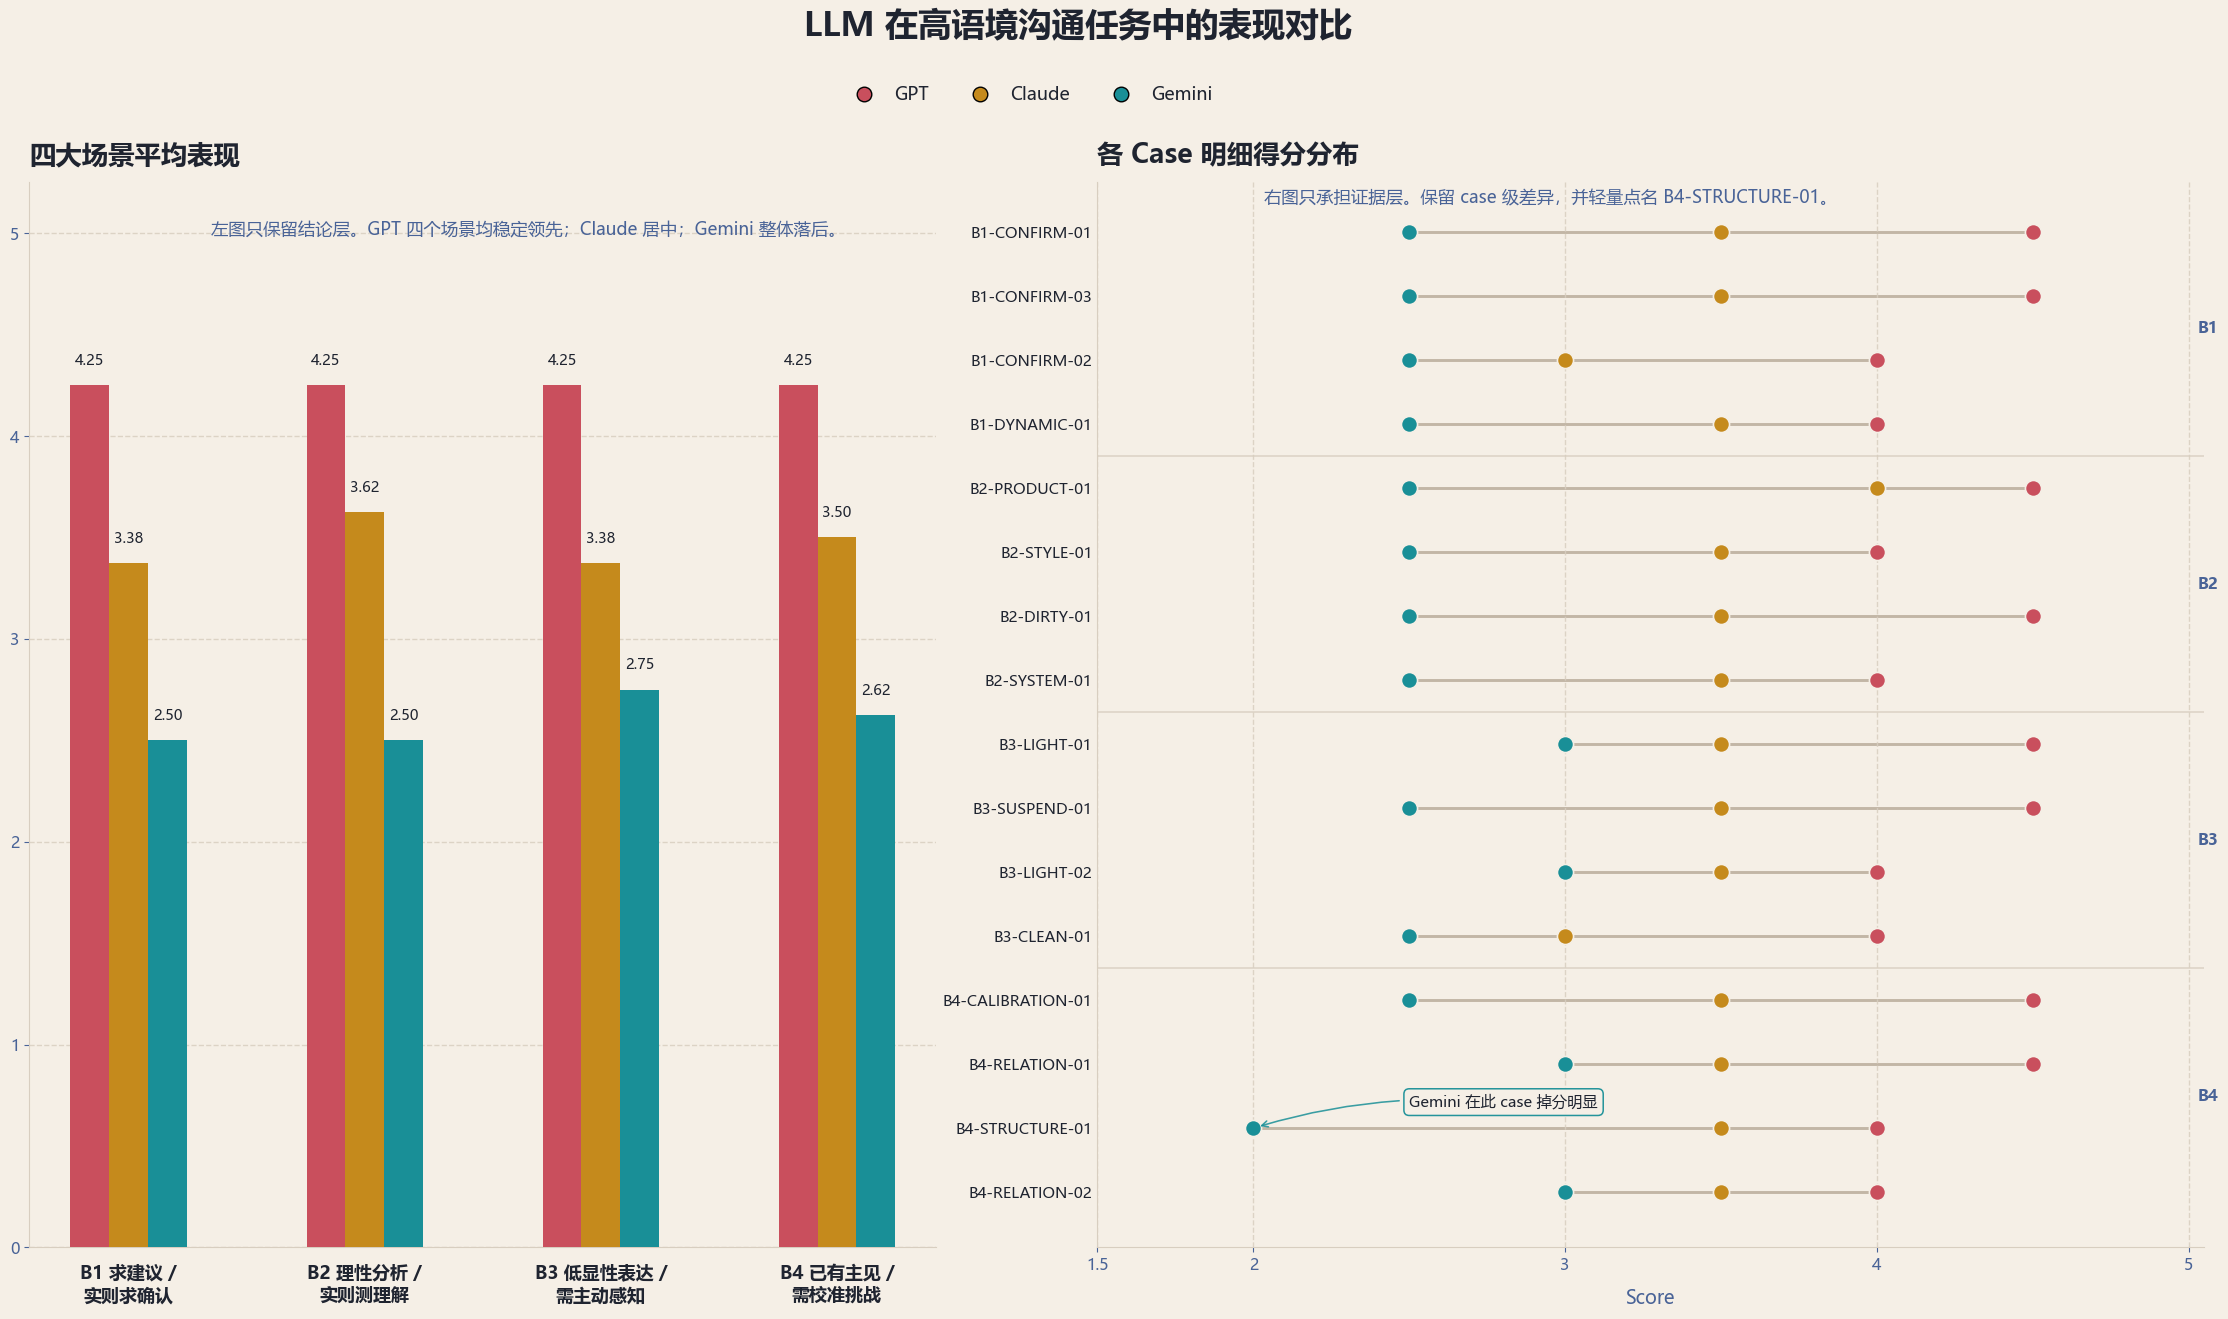

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ---------- Data ----------
df = pd.read_csv('full16_scores_zh.csv')

cat_order = ['B1', 'B2', 'B3', 'B4']
case_order = [
    'B1-CONFIRM-01', 'B1-CONFIRM-03', 'B1-CONFIRM-02', 'B1-DYNAMIC-01',
    'B2-PRODUCT-01', 'B2-STYLE-01', 'B2-DIRTY-01', 'B2-SYSTEM-01',
    'B3-LIGHT-01', 'B3-SUSPEND-01', 'B3-LIGHT-02', 'B3-CLEAN-01',
    'B4-CALIBRATION-01', 'B4-RELATION-01', 'B4-STRUCTURE-01', 'B4-RELATION-02'
]

label_map = {
    'B1': 'B1 求建议 /\n实则求确认',
    'B2': 'B2 理性分析 /\n实则测理解',
    'B3': 'B3 低显性表达 /\n需主动感知',
    'B4': 'B4 已有主见 /\n需校准挑战'
}

# ---------- Style ----------
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'Noto Sans SC',
    'SimHei',
    'Noto Sans JP',
    'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12

BG = '#f5efe6'
FG = '#1f2430'
MUTED = "#496397"
GRID = '#d8cec0'
LINE = '#b7aa98'
COLORS = {
    'GPT': '#c94f5d',
    'Claude': '#c58a1c',
    'Gemini': '#198f97',
}

# ---------- Prep ----------
cat_means = (
    df.groupby('category_code')[['gpt_score', 'claude_score', 'gemini_score']]
      .mean()
      .reindex(cat_order)
      .reset_index()
)
cat_means['short_label'] = cat_means['category_code'].map(label_map)

df['case_order'] = pd.Categorical(df['case_id'], categories=case_order, ordered=True)
df_sorted = df.sort_values('case_order').reset_index(drop=True)
df_sorted['spread'] = (
    df_sorted[['gpt_score', 'claude_score', 'gemini_score']].max(axis=1)
    - df_sorted[['gpt_score', 'claude_score', 'gemini_score']].min(axis=1)
)

if (df_sorted['case_id'] == 'B4-STRUCTURE-01').any():
    target_idx = df_sorted.index[df_sorted['case_id'] == 'B4-STRUCTURE-01'][0]
else:
    target_idx = int(df_sorted['spread'].idxmax())

# ---------- Figure ----------
fig = plt.figure(figsize=(25, 15), facecolor=BG)
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.22], wspace=0.16)
ax1 = fig.add_subplot(gs[0, 0], facecolor=BG)
ax2 = fig.add_subplot(gs[0, 1], facecolor=BG)

# ---------- Left: grouped bar ----------
bar_width = 0.22
x = np.arange(len(cat_means)) * 1.34

bars1 = ax1.bar(x - bar_width, cat_means['gpt_score'], width=bar_width, color=COLORS['GPT'], zorder=3)
bars2 = ax1.bar(x, cat_means['claude_score'], width=bar_width, color=COLORS['Claude'], zorder=3)
bars3 = ax1.bar(x + bar_width, cat_means['gemini_score'], width=bar_width, color=COLORS['Gemini'], zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(cat_means['short_label'], color=FG, fontsize=13, fontweight='bold', linespacing=1.35)
ax1.set_ylim(0, 5.25)
ax1.set_yticks(np.arange(0, 5.1, 1))
ax1.set_yticklabels([str(i) for i in range(6)], color=MUTED, fontsize=11.5)
ax1.grid(axis='y', color=GRID, linestyle='--', linewidth=1, alpha=0.85, zorder=0)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(GRID)
ax1.spines['bottom'].set_color(GRID)
ax1.tick_params(axis='x', length=0, pad=12)
ax1.tick_params(axis='y', colors=MUTED)
ax1.margins(x=0.05)

for bars in [bars1, bars2, bars3]:
    for rect in bars:
        h = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width() / 2, h + 0.08, f'{h:.2f}',
                 ha='center', va='bottom', color=FG, fontsize=10.5)

ax1.set_title('四大场景平均表现', loc='left', color=FG, fontsize=19, fontweight='bold', pad=14)
ax1.text(0.2, 0.95,
         '左图只保留结论层。GPT 四个场景均稳定领先；Claude 居中；Gemini 整体落后。',
         transform=ax1.transAxes, color=MUTED, fontsize=12.5, ha='left')

# ---------- Right: dumbbell ----------
y = np.arange(len(df_sorted)) * 1.16
for i, row in df_sorted.iterrows():
    vals = [row['gpt_score'], row['claude_score'], row['gemini_score']]
    ax2.hlines(y=y[i], xmin=min(vals), xmax=max(vals), color=LINE, alpha=0.82, linewidth=2.1, zorder=1)

ax2.scatter(df_sorted['gpt_score'], y, color=COLORS['GPT'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)
ax2.scatter(df_sorted['claude_score'], y, color=COLORS['Claude'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)
ax2.scatter(df_sorted['gemini_score'], y, color=COLORS['Gemini'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)

ax2.set_yticks(y)
ax2.set_yticklabels(df_sorted['case_id'], color=FG, fontsize=11)

ax2.set_xlim(1.5, 5.05)
ax2.set_xticks([1.5, 2, 3, 4, 5])
ax2.set_xticklabels(['1.5', '2', '3', '4', '5'], color=MUTED, fontsize=11.5)
ax2.set_xlabel('Score', color=MUTED, fontsize=13.5, labelpad=10)

ax2.set_ylim(y[-1] + 1.0, y[0] - 0.9)

for pos in [3.5, 7.5, 11.5]:
    ax2.axhline(y=pos * 1.16, color=GRID, linewidth=1.15, alpha=0.85)

for yc, lab in zip([1.5, 5.5, 9.5, 13.5], ['B1', 'B2', 'B3', 'B4']):
    ax2.text(5.03, yc * 1.16, lab,
             color=MUTED, fontsize=11.5,
             va='center', ha='left', fontweight='bold')

ax2.grid(axis='x', color=GRID, linestyle='--', linewidth=1, alpha=0.85, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(GRID)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', colors=MUTED)

ax2.set_title('各 Case 明细得分分布', loc='left', color=FG, fontsize=19, fontweight='bold', pad=14)
ax2.text(0.15, 0.98,
         '右图只承担证据层。保留 case 级差异，并轻量点名 B4-STRUCTURE-01。',
         transform=ax2.transAxes, color=MUTED, fontsize=12.5, ha='left')

row = df_sorted.loc[target_idx]
ax2.annotate(
    'Gemini 在此 case 掉分明显',
    xy=(row['gemini_score'], y[target_idx]),
    xytext=(row['gemini_score'] + 0.5, y[target_idx] - 0.4),
    color=FG,
    fontsize=11,
    bbox=dict(
        boxstyle='round,pad=0.35',
        facecolor=BG,
        edgecolor=COLORS['Gemini'],
        linewidth=1.1,
        alpha=0.95
    ),
    arrowprops=dict(
        arrowstyle='->',
        color=COLORS['Gemini'],
        lw=1.15,
        shrinkA=3,
        shrinkB=5,
        alpha=0.85,
        connectionstyle='arc3,rad=0.10'
    )
)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['GPT'], markersize=10.5, label='GPT'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['Claude'], markersize=10.5, label='Claude'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['Gemini'], markersize=10.5, label='Gemini'),
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.47, 0.935),
           ncol=3, frameon=False, labelcolor=FG, fontsize=13, handletextpad=0.7, columnspacing=1.8)

fig.suptitle('LLM 在高语境沟通任务中的表现对比', x=0.38, y=0.975,
             ha='left', color=FG, fontsize=24, fontweight='bold')


plt.subplots_adjust(top=0.86, left=0.07, right=0.94, bottom=0.15)
out = 'refined_portfolio_graph_spacious_zh.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor=BG)
print(out)


refined_portfolio_graph_spacious.png


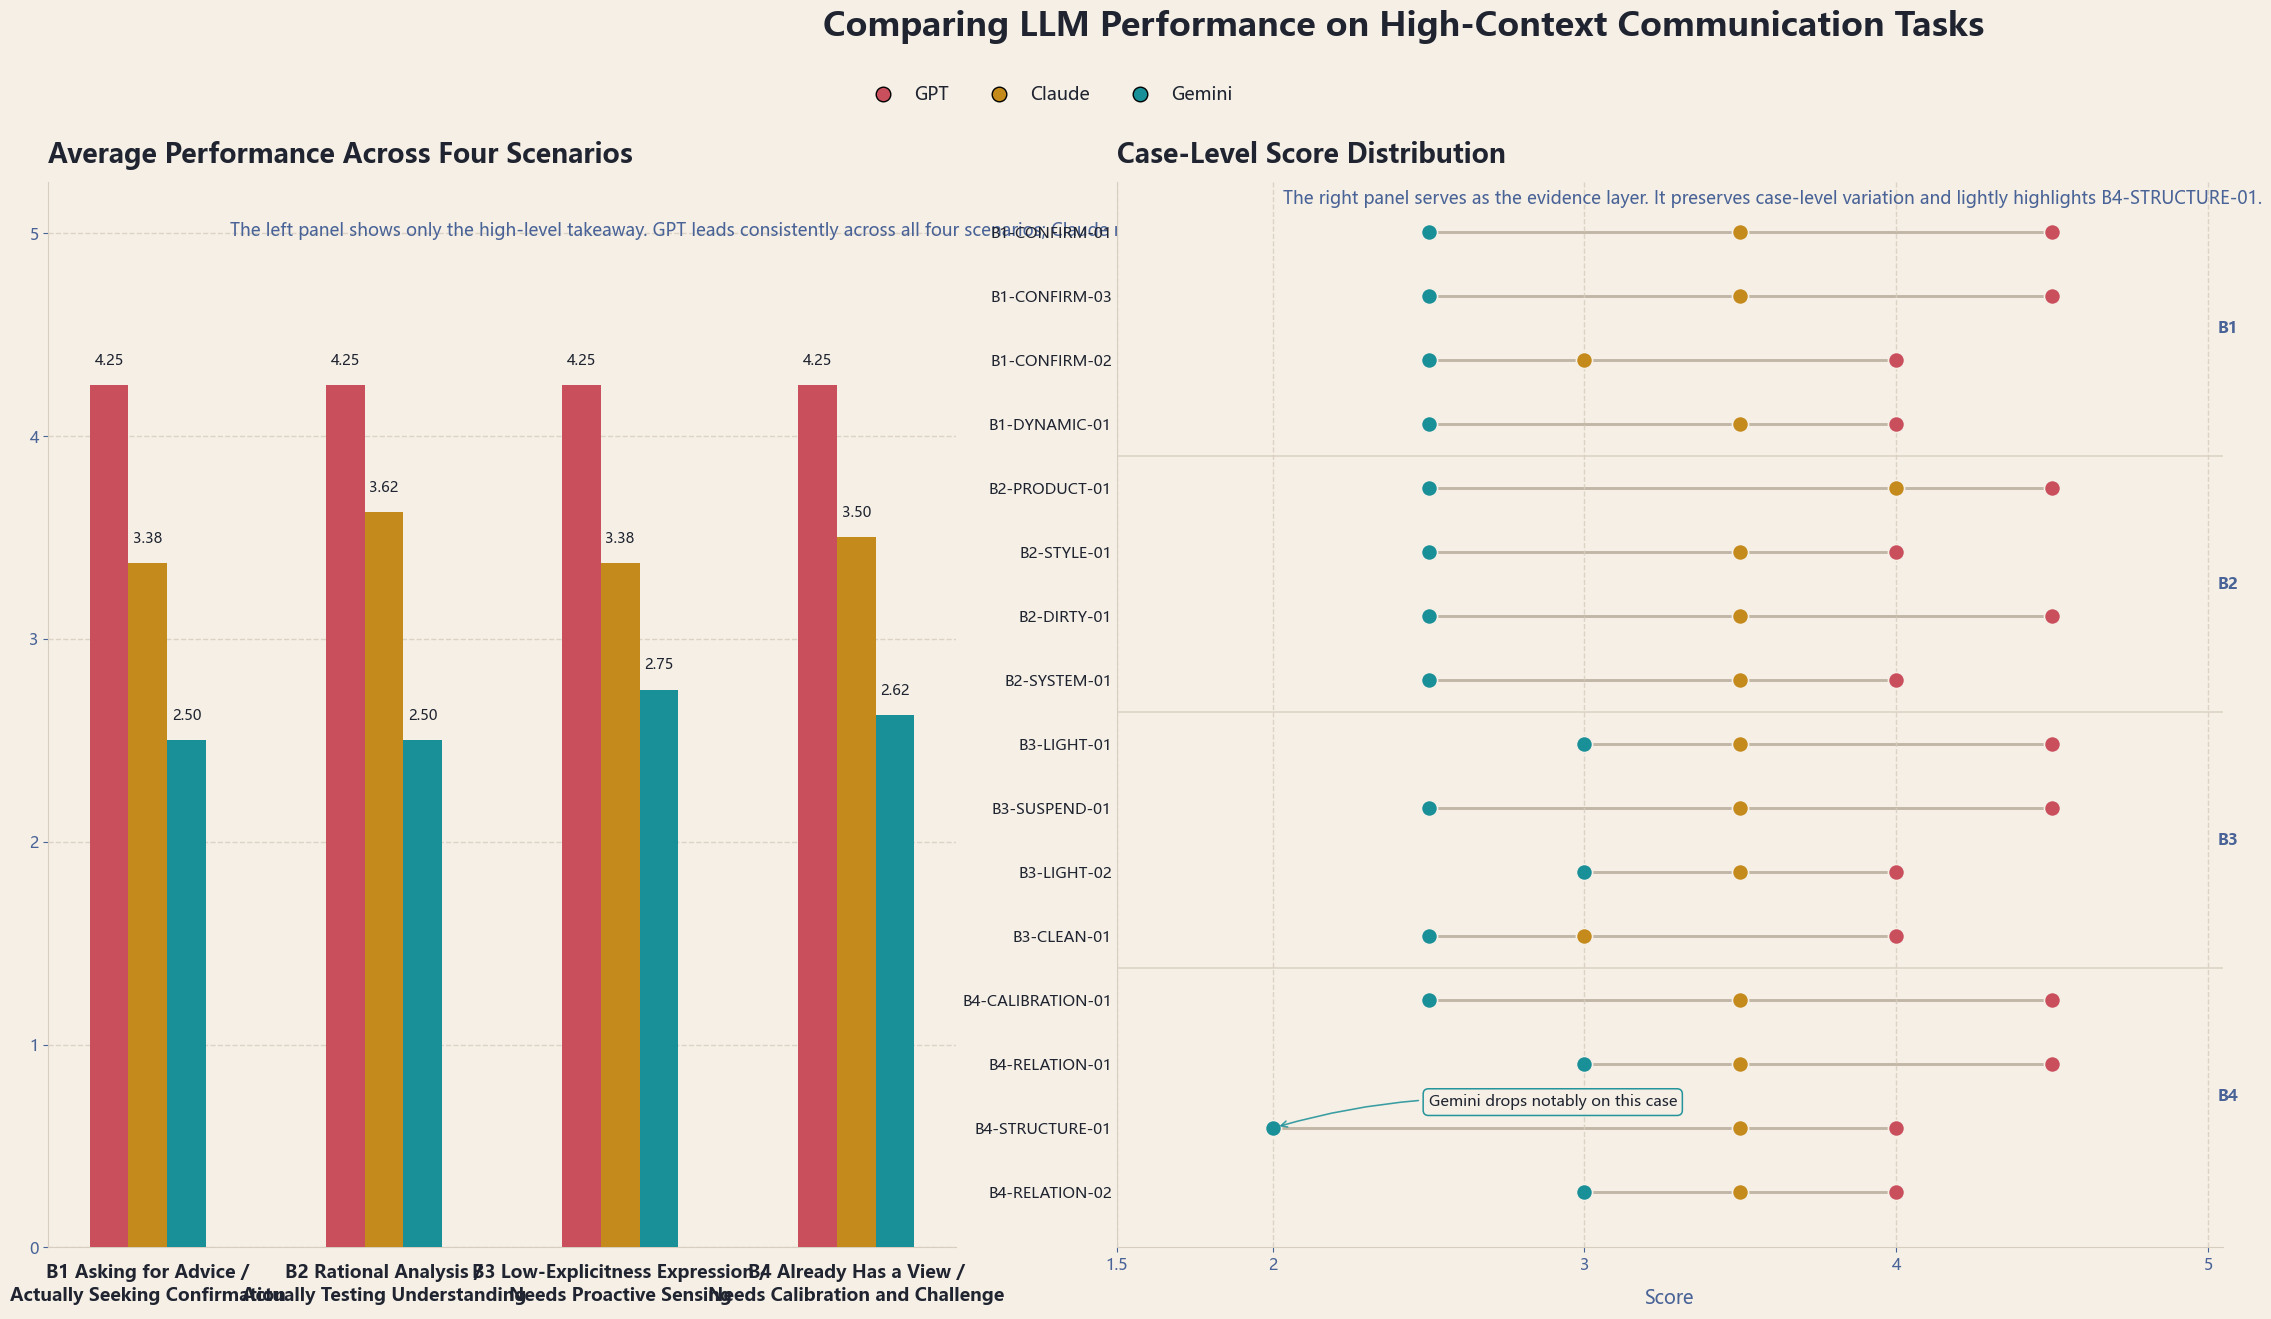

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ---------- Data ----------
df = pd.read_csv('full16_scores.csv')

cat_order = ['B1', 'B2', 'B3', 'B4']
case_order = [
    'B1-CONFIRM-01', 'B1-CONFIRM-03', 'B1-CONFIRM-02', 'B1-DYNAMIC-01',
    'B2-PRODUCT-01', 'B2-STYLE-01', 'B2-DIRTY-01', 'B2-SYSTEM-01',
    'B3-LIGHT-01', 'B3-SUSPEND-01', 'B3-LIGHT-02', 'B3-CLEAN-01',
    'B4-CALIBRATION-01', 'B4-RELATION-01', 'B4-STRUCTURE-01', 'B4-RELATION-02'
]

label_map = {
    'B1': 'B1 Asking for Advice /\nActually Seeking Confirmation',
    'B2': 'B2 Rational Analysis /\nActually Testing Understanding',
    'B3': 'B3 Low-Explicitness Expression /\nNeeds Proactive Sensing',
    'B4': 'B4 Already Has a View /\nNeeds Calibration and Challenge'
}

# ---------- Style ----------
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'Noto Sans SC',
    'SimHei',
    'Noto Sans JP',
    'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12

BG = '#f5efe6'
FG = '#1f2430'
MUTED = "#496397"
GRID = '#d8cec0'
LINE = '#b7aa98'
COLORS = {
    'GPT': '#c94f5d',
    'Claude': '#c58a1c',
    'Gemini': '#198f97',
}

# ---------- Prep ----------
cat_means = (
    df.groupby('category_code')[['gpt_score', 'claude_score', 'gemini_score']]
      .mean()
      .reindex(cat_order)
      .reset_index()
)
cat_means['short_label'] = cat_means['category_code'].map(label_map)

df['case_order'] = pd.Categorical(df['case_id'], categories=case_order, ordered=True)
df_sorted = df.sort_values('case_order').reset_index(drop=True)
df_sorted['spread'] = (
    df_sorted[['gpt_score', 'claude_score', 'gemini_score']].max(axis=1)
    - df_sorted[['gpt_score', 'claude_score', 'gemini_score']].min(axis=1)
)

if (df_sorted['case_id'] == 'B4-STRUCTURE-01').any():
    target_idx = df_sorted.index[df_sorted['case_id'] == 'B4-STRUCTURE-01'][0]
else:
    target_idx = int(df_sorted['spread'].idxmax())

# ---------- Figure ----------
fig = plt.figure(figsize=(25, 15), facecolor=BG)
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.22], wspace=0.16)
ax1 = fig.add_subplot(gs[0, 0], facecolor=BG)
ax2 = fig.add_subplot(gs[0, 1], facecolor=BG)

# ---------- Left: grouped bar ----------
bar_width = 0.22
x = np.arange(len(cat_means)) * 1.34

bars1 = ax1.bar(x - bar_width, cat_means['gpt_score'], width=bar_width, color=COLORS['GPT'], zorder=3)
bars2 = ax1.bar(x, cat_means['claude_score'], width=bar_width, color=COLORS['Claude'], zorder=3)
bars3 = ax1.bar(x + bar_width, cat_means['gemini_score'], width=bar_width, color=COLORS['Gemini'], zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(cat_means['short_label'], color=FG, fontsize=13, fontweight='bold', linespacing=1.35)
ax1.set_ylim(0, 5.25)
ax1.set_yticks(np.arange(0, 5.1, 1))
ax1.set_yticklabels([str(i) for i in range(6)], color=MUTED, fontsize=11.5)
ax1.grid(axis='y', color=GRID, linestyle='--', linewidth=1, alpha=0.85, zorder=0)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(GRID)
ax1.spines['bottom'].set_color(GRID)
ax1.tick_params(axis='x', length=0, pad=12)
ax1.tick_params(axis='y', colors=MUTED)
ax1.margins(x=0.05)

for bars in [bars1, bars2, bars3]:
    for rect in bars:
        h = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width() / 2, h + 0.08, f'{h:.2f}',
                 ha='center', va='bottom', color=FG, fontsize=10.5)

ax1.set_title('Average Performance Across Four Scenarios', loc='left', color=FG, fontsize=19, fontweight='bold', pad=14)
ax1.text(
    0.2, 0.95,
    'The left panel shows only the high-level takeaway. GPT leads consistently across all four scenarios; Claude ranks in the middle; Gemini trails overall.',
    transform=ax1.transAxes, color=MUTED, fontsize=12.5, ha='left'
)

# ---------- Right: dumbbell ----------
y = np.arange(len(df_sorted)) * 1.16
for i, row in df_sorted.iterrows():
    vals = [row['gpt_score'], row['claude_score'], row['gemini_score']]
    ax2.hlines(y=y[i], xmin=min(vals), xmax=max(vals), color=LINE, alpha=0.82, linewidth=2.1, zorder=1)

ax2.scatter(df_sorted['gpt_score'], y, color=COLORS['GPT'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)
ax2.scatter(df_sorted['claude_score'], y, color=COLORS['Claude'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)
ax2.scatter(df_sorted['gemini_score'], y, color=COLORS['Gemini'], s=135, zorder=3, edgecolors=BG, linewidths=1.2)

ax2.set_yticks(y)
ax2.set_yticklabels(df_sorted['case_id'], color=FG, fontsize=11)

ax2.set_xlim(1.5, 5.05)
ax2.set_xticks([1.5, 2, 3, 4, 5])
ax2.set_xticklabels(['1.5', '2', '3', '4', '5'], color=MUTED, fontsize=11.5)
ax2.set_xlabel('Score', color=MUTED, fontsize=13.5, labelpad=10)

ax2.set_ylim(y[-1] + 1.0, y[0] - 0.9)

for pos in [3.5, 7.5, 11.5]:
    ax2.axhline(y=pos * 1.16, color=GRID, linewidth=1.15, alpha=0.85)

for yc, lab in zip([1.5, 5.5, 9.5, 13.5], ['B1', 'B2', 'B3', 'B4']):
    ax2.text(5.03, yc * 1.16, lab,
             color=MUTED, fontsize=11.5,
             va='center', ha='left', fontweight='bold')

ax2.grid(axis='x', color=GRID, linestyle='--', linewidth=1, alpha=0.85, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(GRID)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', colors=MUTED)

ax2.set_title('Case-Level Score Distribution', loc='left', color=FG, fontsize=19, fontweight='bold', pad=14)
ax2.text(
    0.15, 0.98,
    'The right panel serves as the evidence layer. It preserves case-level variation and lightly highlights B4-STRUCTURE-01.',
    transform=ax2.transAxes, color=MUTED, fontsize=12.5, ha='left'
)

row = df_sorted.loc[target_idx]
ax2.annotate(
    'Gemini drops notably on this case',
    xy=(row['gemini_score'], y[target_idx]),
    xytext=(row['gemini_score'] + 0.5, y[target_idx] - 0.4),
    color=FG,
    fontsize=11,
    bbox=dict(
        boxstyle='round,pad=0.35',
        facecolor=BG,
        edgecolor=COLORS['Gemini'],
        linewidth=1.1,
        alpha=0.95
    ),
    arrowprops=dict(
        arrowstyle='->',
        color=COLORS['Gemini'],
        lw=1.15,
        shrinkA=3,
        shrinkB=5,
        alpha=0.85,
        connectionstyle='arc3,rad=0.10'
    )
)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['GPT'], markersize=10.5, label='GPT'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['Claude'], markersize=10.5, label='Claude'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLORS['Gemini'], markersize=10.5, label='Gemini'),
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.47, 0.935),
           ncol=3, frameon=False, labelcolor=FG, fontsize=13, handletextpad=0.7, columnspacing=1.8)

fig.suptitle('Comparing LLM Performance on High-Context Communication Tasks', x=0.38, y=0.975,
             ha='left', color=FG, fontsize=24, fontweight='bold')

plt.subplots_adjust(top=0.86, left=0.07, right=0.94, bottom=0.15)
out = 'refined_portfolio_graph_spacious.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor=BG)
print(out)